In [3]:
# Step 1: shap_cnn.ipynb is to apply to 1D-CNN model
# Using kernelExplainer(model-agnostic)
# KernelExplainer works on ANY model
# slower than TreeExplainer but universal

import numpy as np
import pandas as pd
import shap
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import time

print(f"TensorFlow: {tf.__version__}")
print("Libraries loaded!")

TensorFlow: 2.16.2
Libraries loaded!


In [6]:
# Step 2: Load data and CNN model
print("Loading data and model...")

save_path = "/Users/miuyanhong/Desktop/replication_studies/XAI_Feature_Selection/CICIDS-2017/processed/"

# Load data
X_train = np.load(save_path + "X_train.npy")
X_test = np.load(save_path + "X_test.npy")
y_test = pd.read_csv(save_path + "y_test.csv").squeeze()

# Reshape for CNN
X_train_cnn = X_train.reshape(
                  X_train.shape[0], X_train.shape[1],1)
X_test_cnn = X_test.reshape(
    X_test.shape[0],X_test.shape[1],1)

# Load CNN model
model = keras.models.load_model(
    save_path + "cnn_model.keras")

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print("Data and model loaded!")


Loading data and model...
X_train: (1979513, 80)
X_test: (848363, 80)
Data and model loaded!


In [8]:
# Step 3: Get features names and sample
import glob

# Get feature names
path = "/Users/miuyanhong/Desktop/replication_studies/XAI_Feature_Selection/CICIDS-2017/cicids_db/*.csv"
files = glob.glob(path)
df_sample = pd.read_csv(files[0],nrows=5)
df_sample.columns= df_sample.columns.str.strip()

non_numeric = ['Flow ID', 'Source IP',
              'Destination IP', 'Timestamp',
              'Label']
feature_names = [c for c in df_sample.columns
                if c not in non_numeric]
print(f"Features: {len(feature_names)}")

# Take small sample for SHAP
# KernelExplainer is slow
# 100 samples = reasonable time
np.random.seed(42)
sample_idx = np.random.choice(
    len(X_test), size=100, replace=False)
X_sample = X_test[sample_idx]
X_sample_cnn = X_sample.reshape(
    X_sample.shape[0], X_sample.shape[1],1)

print(f"Sample size: {X_sample.shape}")
print("Ready for SHAP!")


Features: 80
Sample size: (100, 80)
Ready for SHAP!


In [9]:
# Step 4: Create SHAP KernelExplainer
# KernelExplainer works on ANY model
# Needs background dataset (summary of training)
# background = 50 sameples from training data

print("Creating SHAP KernelExplainer...")
print("This may take 2-3 minutes...")

# Create prediction function for CNN
# SHAP needs flat input (not 3D)
def predict_fn(x):
    # Reshape flat input to CNN format
    x_reshaped = x.reshape(
        x.shape[0], x.shape[1],1)
    return model.predict(
        x_reshaped, verbose = 0)

# Background dataset
# = summary of training data
# = 50 samples is enough
background = X_train[:50]

# Create explainer
explainer = shap.KernelExplainer(
    predict_fn, background)
print("SHAP KernelExplainer created!")

Creating SHAP KernelExplainer...
This may take 2-3 minutes...
SHAP KernelExplainer created!


In [10]:
# Step 5: Calculate SHAP values
print("Calculating SHAP values...")
print("Please wait 30-45 minutes...")

start_time = time.time()

shap_values = explainer.shap_values(
    X_sample,
    nsamples=100  # perturbations per sample
)

end_time = time.time()
shap_time = round(end_time - start_time, 2)

print(f"SHAP complete!")
print(f"Time: {shap_time} seconds")
print(f"Type: {type(shap_values)}")

if isinstance(shap_values, list):
    print(f"Classes: {len(shap_values)}")
    print(f"Shape: {shap_values[0].shape}")
else:
    print(f"Shape: {shap_values.shape}")

Calculating SHAP values...
Please wait 30-45 minutes...


  0%|          | 0/100 [00:00<?, ?it/s]

/opt/miniconda3/envs/cnn_env/lib/python3.9/site-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 7 iterations, i.e. alpha=4.746e-03, with an active set of 7 regressors, and the smallest cholesky pivot element being 2.220e-16. Reduce max_iter or increase eps parameters.
  warnings.warn(
/opt/miniconda3/envs/cnn_env/lib/python3.9/site-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 6 iterations, i.e. alpha=1.607e-03, with an active set of 6 regressors, and the smallest cholesky pivot element being 5.960e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(


SHAP complete!
Time: 119.27 seconds
Type: <class 'numpy.ndarray'>
Shape: (100, 80, 13)


Generating SHAP plot...


/var/folders/28/cggd8l710jz37nj7nfdl032r0000gn/T/ipykernel_34486/4177132420.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


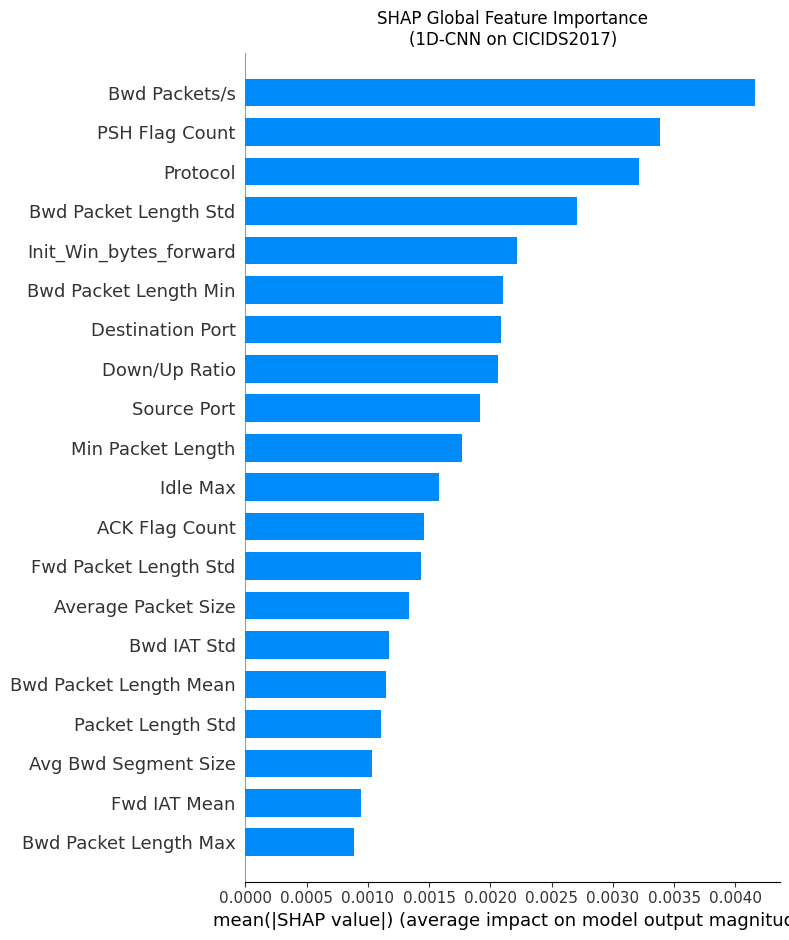

SHAP CNN plot saved!


In [13]:
# Step 6: Plot SHAP global feature importance
print("Generating SHAP plot...")

shap_mean = np.mean(
    np.abs(shap_values), axis=2)

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_mean,
    X_sample,
    feature_names=feature_names,
    plot_type="bar",
    max_display=20,
    show=False
)
plt.title("SHAP Global Feature Importance\n(1D-CNN on CICIDS2017)")
plt.tight_layout()
plt.savefig(save_path + "shap_cnn_global.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("SHAP CNN plot saved!")

In [14]:
# Step 7: Save SHAP results to JSON
import json

shap_importance = np.mean(shap_mean, axis=0)
top_indices = np.argsort(
    shap_importance)[::-1][:10]

top_features = [
    {"feature": feature_names[i],
    "importance": float(shap_importance[i])}
    for i in top_indices
]

shap_cnn_results = {
    "method": "SHAP",
    "model": "1D-CNN",
    "dataset": "KernelExplainer",
    "samples": 100,
    "time_seconds": shap_time,
    "top_10_features": top_features
}

with open(save_path + "shap_cnn_results.json",
         "w") as f:
    json.dump(shap_cnn_results, f, indent=4)

print("SHAP CNN results saved!")
print("\nTop 5 features:")
for f in top_features[:5]:
    print(f" {f['feature']}: {f['importance']:.4f}")
    

SHAP CNN results saved!

Top 5 features:
 Bwd Packets/s: 0.0042
 PSH Flag Count: 0.0034
 Protocol: 0.0032
 Bwd Packet Length Std: 0.0027
 Init_Win_bytes_forward: 0.0022


In [16]:
# Step 8: Copy results to benchmark repo
import shutil

benchmark = "/Users/miuyanhong/Desktop/TCSS499_Research_Benchmark/results/"

shutil.copy(save_path + "shap_cnn_global.png",
            benchmark + "shap_cnn_global.png")
shutil.copy(save_path + "shap_cnn_results.json",
           benchmark + "shap_cnn_results.json")
print("Files copied to benchmark repo!")

Files copied to benchmark repo!
